# Stock Price Prediction Using RNNs

## Objective
The objective of this assignment is to try and predict the stock prices using historical data from four companies IBM (IBM), Google (GOOGL), Amazon (AMZN), and Microsoft (MSFT).

We use four different companies because they belong to the same sector: Technology. Using data from all four companies may improve the performance of the model. This way, we can capture the broader market sentiment.

The problem statement for this assignment can be summarised as follows:

> Given the stock prices of Amazon, Google, IBM, and Microsoft for a set number of days, predict the stock price of these companies after that window.

## Business Value

Data related to stock markets lends itself well to modeling using RNNs due to its sequential nature. We can keep track of opening prices, closing prices, highest prices, and so on for a long period of time as these values are generated every working day. The patterns observed in this data can then be used to predict the future direction in which stock prices are expected to move. Analyzing this data can be interesting in itself, but it also has a financial incentive as accurate predictions can lead to massive profits.

### **Data Description**

You have been provided with four CSV files corresponding to four stocks: AMZN, GOOGL, IBM, and MSFT. The files contain historical data that were gathered from the websites of the stock markets where these companies are listed: NYSE and NASDAQ. The columns in all four files are identical. Let's take a look at them:

- `Date`: The values in this column specify the date on which the values were recorded. In all four files, the dates range from Jaunary 1, 2006 to January 1, 2018.

- `Open`: The values in this column specify the stock price on a given date when the stock market opens.

- `High`: The values in this column specify the highest stock price achieved by a stock on a given date.

- `Low`: The values in this column specify the lowest stock price achieved by a stock on a given date.

- `Close`: The values in this column specify the stock price on a given date when the stock market closes.

- `Volume`: The values in this column specify the total number of shares traded on a given date.

- `Name`: This column gives the official name of the stock as used in the stock market.

There are 3019 records in each data set. The file names are of the format `\<company_name>_stock_data.csv`.

## **1 Data Loading and Preparation** <font color =red> [25 marks] </font>

#### **Import Necessary Libraries**

In [52]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error,mean_squared_error


### **1.1 Data Aggregation** <font color =red> [7 marks] </font>

As we are using the stock data for four different companies, we need to create a new DataFrame that contains the combined data from all four data frames. We will create a function that takes in a list of the file names for the four CSV files, and returns a single data frame. This function performs the following tasks:
- Extract stock names from file names
- Read the CSV files as data frames
- Append the stock names into the columns of their respective data frames
- Drop unnecessary columns
- Join the data frames into one.

#### **1.1.1** <font color =red> [5 marks] </font>
Create the function to join DataFrames and use it to combine the four datasets.

In [13]:
# Define a function to load data and aggregate them
def loadAndAggDataFromFiles(files):
    dfs=[]  #to store the final dfs
    for file in files:
        df=pd.read_csv('./RNN_Stocks_Data/'+file,parse_dates=["Date"])
        companyName=df["Name"].iloc[0]
        df=df.drop(columns=["Name"])
        df=df.rename(columns={col:f"{col}{companyName}" for col in df.columns if col!='Date'})
        dfs.append(df)
    df_merged=reduce(lambda left,right: pd.merge(left,right,on='Date',how='outer'),dfs)
    df_merged=df_merged.sort_values("Date").reset_index(drop=True)
    return df_merged




In [14]:
# Specify the names of the raw data files to be read and use the aggregation function to read the files
file=['AMZN_stocks_data.csv','GOOGL_stocks_data.csv','IBM_stocks_data.csv','MSFT_stocks_data.csv']
final_df=loadAndAggDataFromFiles(file)
final_df.head()



,Date,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,...,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT
0,2006-01-03,47.47,47.85,46.25,47.58,7582127.0,211.47,218.05,209.32,217.83,...,82.45,82.55,80.81,82.06,11715200,26.25,27.00,26.10,26.84,79974418.0
1,2006-01-04,47.48,47.73,46.69,47.25,7440914.0,222.17,224.70,220.09,222.84,...,82.20,82.50,81.33,81.95,9840600,26.77,27.08,26.77,26.97,57975661.0
2,2006-01-05,47.16,48.20,47.11,47.65,5417258.0,223.22,226.00,220.97,225.85,...,81.40,82.90,81.00,82.50,7213500,26.96,27.13,26.91,26.99,48247610.0
3,2006-01-06,47.97,48.58,47.32,47.87,6154285.0,228.66,235.49,226.85,233.06,...,83.95,85.03,83.41,84.95,8197400,26.89,27.00,26.49,26.91,100969092.0
4,2006-01-09,46.55,47.10,46.40,47.08,8945056.0,233.44,236.94,230.70,233.68,...,84.10,84.25,83.38,83.73,6858200,26.93,27.07,26.76,26.86,55627836.0


In [15]:
# View specifics of the data
final_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3020 non-null   datetime64[ns]
 1   OpenAMZN     3019 non-null   float64       
 2   HighAMZN     3019 non-null   float64       
 3   LowAMZN      3019 non-null   float64       
 4   CloseAMZN    3019 non-null   float64       
 5   VolumeAMZN   3019 non-null   float64       
 6   OpenGOOGL    3019 non-null   float64       
 7   HighGOOGL    3019 non-null   float64       
 8   LowGOOGL     3019 non-null   float64       
 9   CloseGOOGL   3019 non-null   float64       
 10  VolumeGOOGL  3019 non-null   float64       
 11  OpenIBM      3019 non-null   float64       
 12  HighIBM      3020 non-null   float64       
 13  LowIBM       3019 non-null   float64       
 14  CloseIBM     3020 non-null   float64       
 15  VolumeIBM    3020 non-null   int64         
 16  OpenMS

In [16]:
final_df.describe()

,Date,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,...,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT
count,3020,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03,3019.000000,3019.000000,3019.000000,3019.000000,...,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03
mean,2012-01-01 14:54:59.602649088,299.335310,302.371163,296.037695,299.376231,5.931712e+06,428.200802,431.835618,424.130275,428.044001,...,145.515545,146.681738,144.471597,145.617278,5.773301e+06,36.496817,36.827903,36.173190,36.513412,5.161762e+07
min,2006-01-03 00:00:00,26.090000,26.300000,25.760000,26.070000,9.864350e+05,131.390000,134.820000,123.770000,128.850000,...,72.740000,73.940000,69.500000,71.740000,2.542560e+05,15.200000,15.620000,14.870000,15.150000,7.425603e+06
25%,2009-01-01 12:00:00,81.175000,82.580000,79.725000,81.090000,3.137037e+06,247.775000,250.190000,244.035000,247.605000,...,116.405000,117.765000,115.490000,116.525000,3.622681e+06,26.785000,27.045000,26.535000,26.835000,3.136557e+07
50%,2011-12-29 12:00:00,205.330000,208.000000,202.100000,205.440000,4.724100e+06,310.480000,312.810000,307.790000,310.080000,...,149.610000,150.330000,148.470000,149.315000,4.928852e+06,29.990000,30.230000,29.780000,30.000000,4.617529e+07
75%,2014-12-31 12:00:00,375.570000,379.155000,373.000000,375.140000,7.135246e+06,572.140000,575.975000,565.900000,570.770000,...,178.445000,179.762500,177.330000,178.685000,6.965014e+06,44.545000,44.980000,44.090000,44.400000,6.322291e+07
max,2017-12-29 00:00:00,1204.880000,1213.410000,1191.150000,1195.830000,1.044046e+08,1083.020000,1086.490000,1072.270000,1085.090000,...,215.380000,215.900000,214.300000,215.800000,3.077428e+07,87.120000,87.500000,86.230000,86.850000,5.910786e+08
std,NaN,280.120547,281.826442,277.927134,279.980161,5.122034e+06,236.320026,237.514087,234.923747,236.343238,...,37.554946,37.613446,37.477641,37.529387,3.192831e+06,14.683337,14.742483,14.620057,14.694656,3.114958e+07


#### **1.1.2** <font color =red> [2 marks] </font>
Identify and handle any missing values.

In [17]:
# Handle Missing Values
final_df.isna().sum(axis=0)


Date           0
OpenAMZN       1
HighAMZN       1
LowAMZN        1
CloseAMZN      1
VolumeAMZN     1
OpenGOOGL      1
HighGOOGL      1
LowGOOGL       1
CloseGOOGL     1
VolumeGOOGL    1
OpenIBM        1
HighIBM        0
LowIBM         1
CloseIBM       0
VolumeIBM      0
OpenMSFT       1
HighMSFT       1
LowMSFT        1
CloseMSFT      1
VolumeMSFT     1
dtype: int64

In [18]:
final_df[final_df.isna().any(axis=1)]

,Date,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,...,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT
1068,2010-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,128.95,129.31,127.55,128.25,4980625,NaN,NaN,NaN,NaN,NaN
2913,2017-07-31,1019.05,1019.05,987.02,987.78,7352063.0,960.0,961.19,941.72,945.5,...,NaN,144.93,NaN,144.67,4355718,73.3,73.44,72.41,72.7,23600054.0


In [19]:
final_df=final_df[~(final_df['Date']=='2010-04-01')]

In [20]:
# Chechking the remaining NA values
final_df[final_df.isna().any(axis=1)]

,Date,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,...,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT
2913,2017-07-31,1019.05,1019.05,987.02,987.78,7352063.0,960.0,961.19,941.72,945.5,...,NaN,144.93,NaN,144.67,4355718,73.3,73.44,72.41,72.7,23600054.0


In [21]:
# Replacing the NA values with the Median
final_df = final_df.fillna(final_df.median(numeric_only=True))

In [22]:
final_df[final_df.isna().any(axis=1)]

,Date,OpenAMZN,HighAMZN,LowAMZN,CloseAMZN,VolumeAMZN,OpenGOOGL,HighGOOGL,LowGOOGL,CloseGOOGL,...,OpenIBM,HighIBM,LowIBM,CloseIBM,VolumeIBM,OpenMSFT,HighMSFT,LowMSFT,CloseMSFT,VolumeMSFT


In [23]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3019 entries, 0 to 3019
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3019 non-null   datetime64[ns]
 1   OpenAMZN     3019 non-null   float64       
 2   HighAMZN     3019 non-null   float64       
 3   LowAMZN      3019 non-null   float64       
 4   CloseAMZN    3019 non-null   float64       
 5   VolumeAMZN   3019 non-null   float64       
 6   OpenGOOGL    3019 non-null   float64       
 7   HighGOOGL    3019 non-null   float64       
 8   LowGOOGL     3019 non-null   float64       
 9   CloseGOOGL   3019 non-null   float64       
 10  VolumeGOOGL  3019 non-null   float64       
 11  OpenIBM      3019 non-null   float64       
 12  HighIBM      3019 non-null   float64       
 13  LowIBM       3019 non-null   float64       
 14  CloseIBM     3019 non-null   float64       
 15  VolumeIBM    3019 non-null   int64         
 16  OpenMSFT   

### **1.2 Analysis and Visualisation** <font color =red> [5 marks] </font>

#### **1.2.1** <font color =red> [2 marks] </font>
Analyse the frequency distribution of stock volumes of the companies and also see how the volumes vary over time.

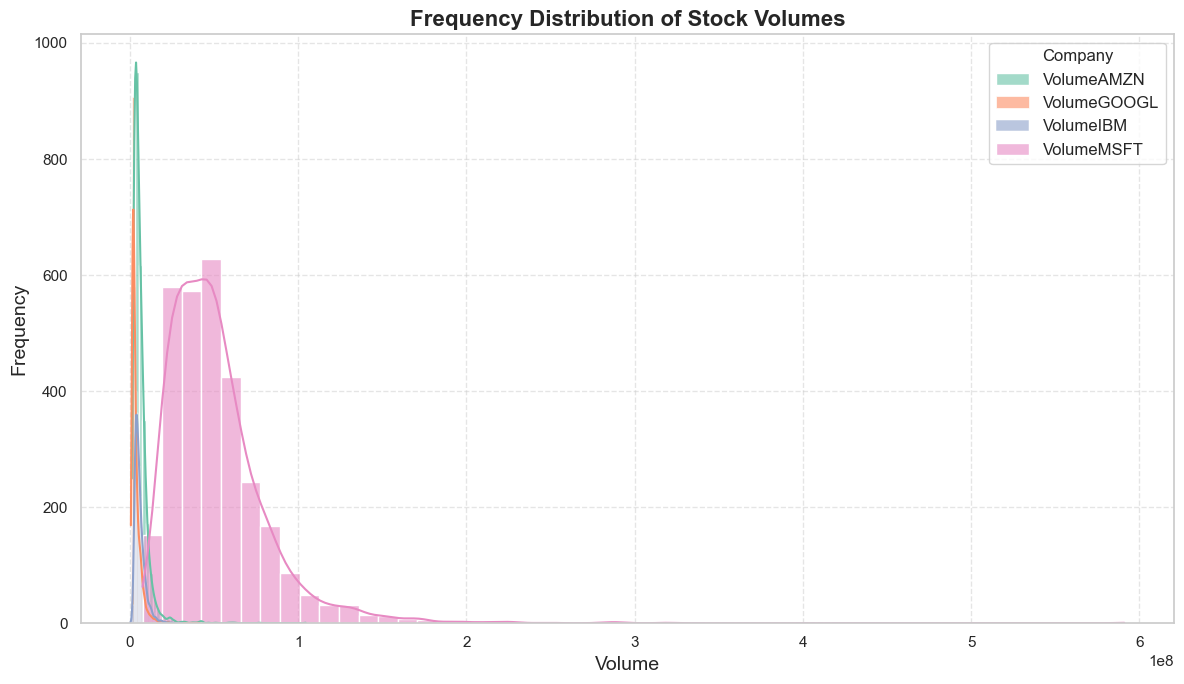

In [24]:
# Frequency distribution of volumes
volume_cols = [col for col in final_df.columns if "volume" in col.lower()]

plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")  # nicer background
colors = sns.color_palette("Set2", len(volume_cols))
for i, col in enumerate(volume_cols):
    sns.histplot(final_df[col], bins=50, kde=True, color=colors[i], alpha=0.6, label=col)
plt.title("Frequency Distribution of Stock Volumes", fontsize=16, weight="bold")
plt.xlabel("Volume", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


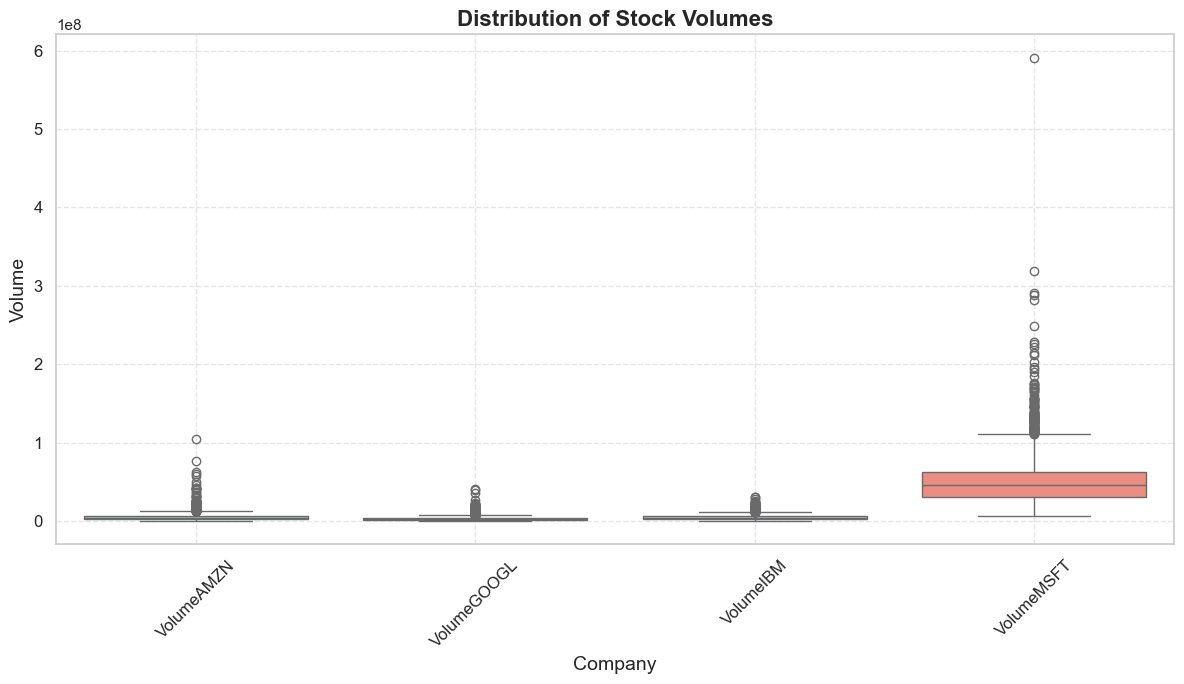

In [25]:
# BoxPlot
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")
colors = sns.color_palette("Set3", len(volume_cols))
sns.boxplot(data=final_df[volume_cols], palette=colors)
plt.title("Distribution of Stock Volumes", fontsize=16, weight="bold")
plt.ylabel("Volume", fontsize=14)
plt.xlabel("Company", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

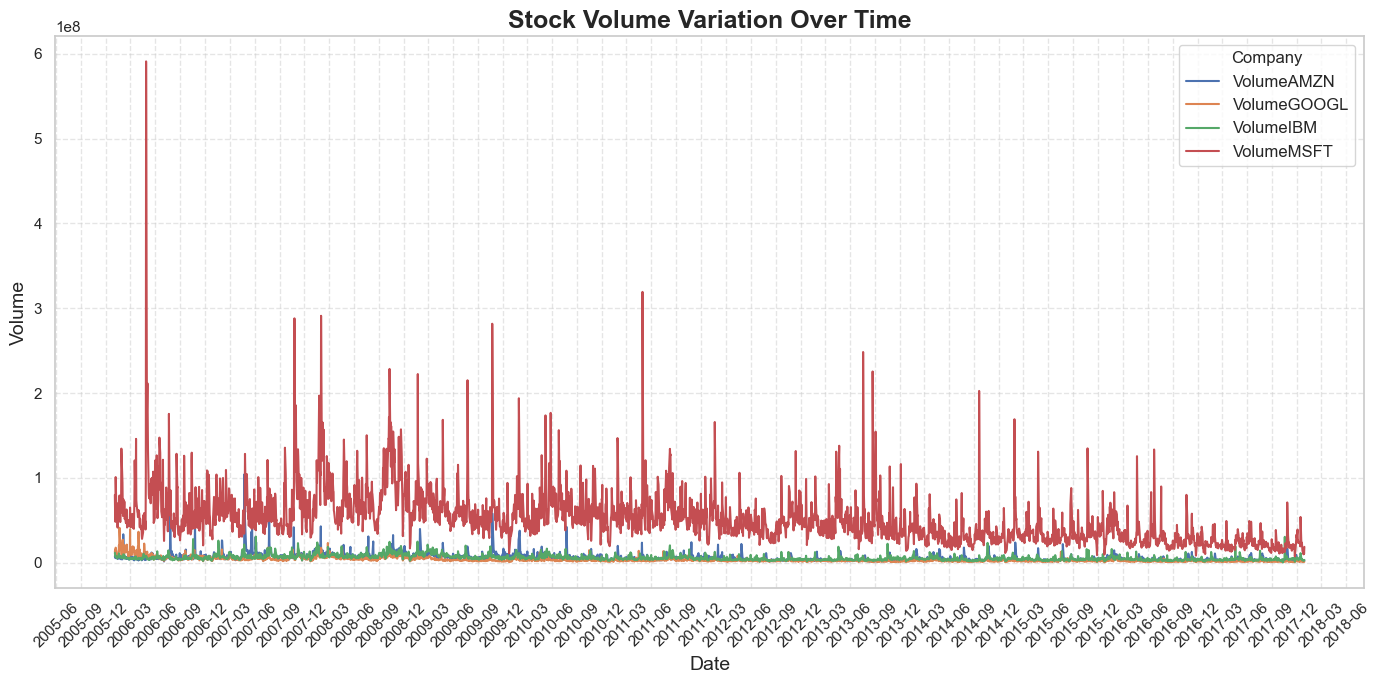

In [26]:
# Stock volume variation over time
plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")
for i, col in enumerate(volume_cols):
    plt.plot(final_df["Date"], final_df[col], label=col)

plt.title("Stock Volume Variation Over Time", fontsize=18, weight="bold")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Volume", fontsize=14)
plt.legend(title="Company", fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))  
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### **1.2.2** <font color =red> [3 marks] </font>
Analyse correlations between features.

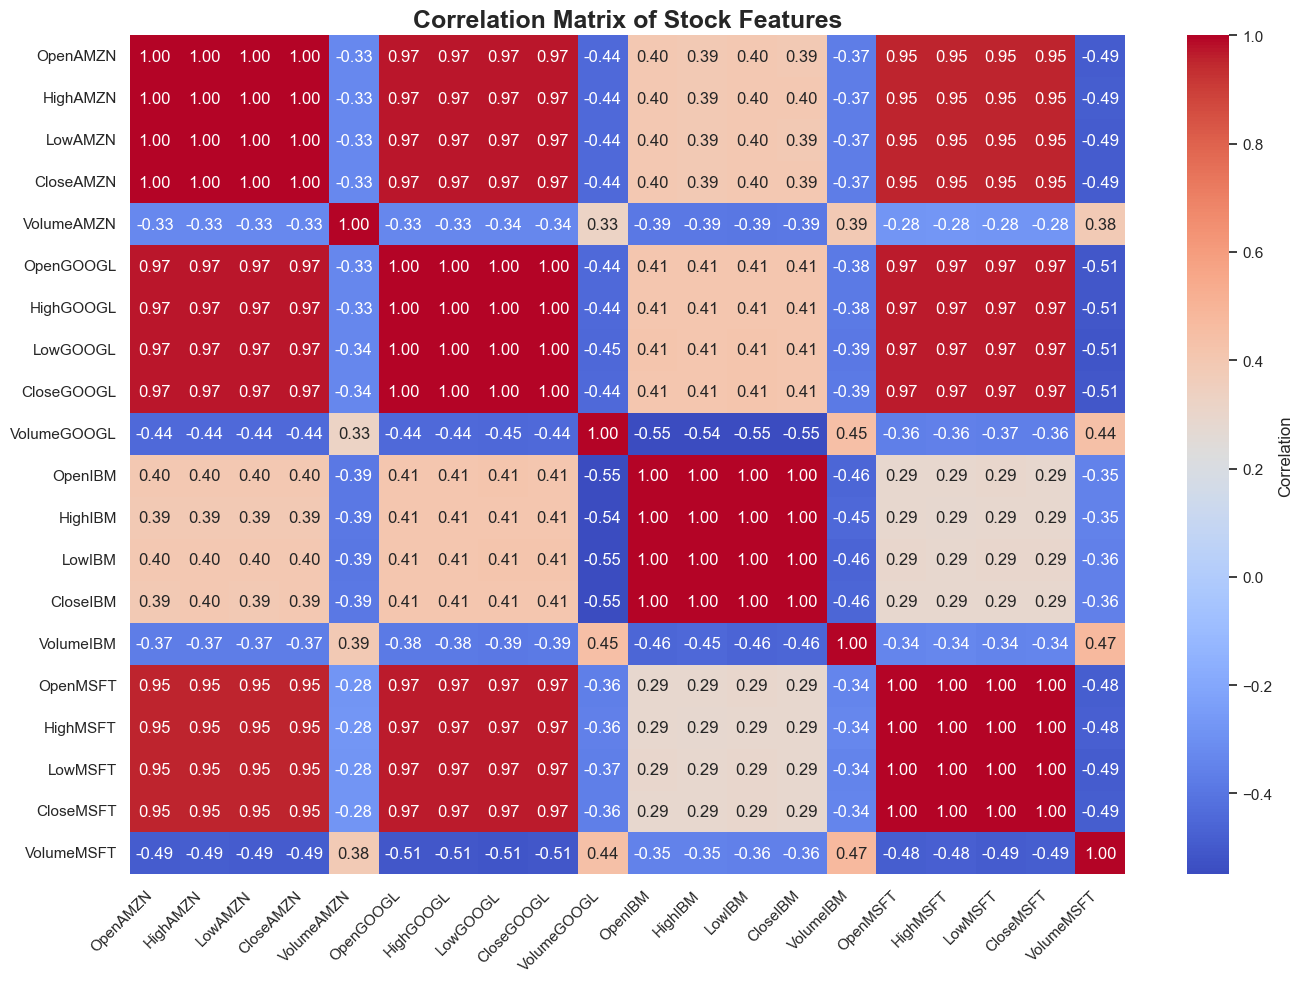

In [27]:
# Analyse correlations
corr_matrix = final_df.drop(columns=["Date"]).corr()
plt.figure(figsize=(14, 10))
sns.set(style="white")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix of Stock Features", fontsize=18, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### **1.3 Data Processing** <font color =red> [13 marks] </font>

Next, we need to process the data so that it is ready to be used in recurrent neural networks. You know RNNs are suitable to work with sequential data where patterns repeat at regular intervals.

For this, we need to execute the following steps:
1. Create windows from the master data frame and obtain windowed `X` and corresponding windowed `y` values
2. Perform train-test split on the windowed data
3. Scale the data sets in an appropriate manner

We will define functions for the above steps that finally return training and testing data sets that are ready to be used in recurrent neural networks.

**Hint:** If we use a window of size 3, in the first window, the rows `[0, 1, 2]` will be present and will be used to predict the value of `CloseAMZN` in row `3`. In the second window, rows `[1, 2, 3]` will be used to predict `CloseAMZN` in row `4`.

#### **1.3.1** <font color =red> [3 marks] </font>
Create a function that returns the windowed `X` and `y` data.

From the main DataFrame, this function will create windowed DataFrames, and store those as a list of DataFrames.

Controllable parameters will be window size, step size (window stride length) and target names as a list of the names of stocks whose closing values we wish to predict.

In [28]:
# Define a function that divides the data into windows and generates target variable values for each window
def createWindowedData(df,window_size=3,step_size=1,target_names=None):
    X= []
    y= []
    total_rows = len(df)
    for start in range(0, total_rows - window_size, step_size):
        end = start + window_size
        X.append(df.iloc[start:end].reset_index(drop=True))
        if target_names:
            y.append(df.iloc[end][target_names])
        else:
            y.append(df.iloc[end])  # all columns if target_names not given
    
    return X, y



#### **1.3.2** <font color =red> [3 marks] </font>
Create a function to scale the data.

Define a function that will scale the data.

For scaling, we have to look at the whole length of data to find max/min values or standard deviations and means. If we scale the whole data at once, this will lead to data leakage in the windows. This is not necessarily a problem if the model is trained on the complete data with cross-validation.

One way to scale when dealing with windowed data is to use the `partial_fit()` method.
```
scaler.partial_fit(window)
scaler.transform(window)
```
You may use any other suitable way to scale the data properly. Arrive at a reasonable way to scale your data.

In [29]:
# Define a function that scales the windowed data
# The function takes in the windowed data sets and returns the scaled windows
def scaledWindowedData(X_windows):
    scaler = StandardScaler()
    X_scaled = []
    # Fit scaler progressively to avoid leakage
    for window in X_windows:
        scaler.partial_fit(window)
    # Transform all windows
    for window in X_windows:
        X_scaled.append(scaler.transform(window))

    return X_scaled, scaler #Returning scaler object as well 


Next, define the main function that will call the windowing and scaling helper functions.

The input parameters for this function are:
- The joined master data set
- The names of the stocks that we wish to predict the *Close* prices for
- The window size
- The window stride
- The train-test split ratio

The outputs from this function are the scaled dataframes:
- *X_train*
- *y_train*
- *X_test*
- *y_test*

#### **1.3.3** <font color =red> [3 marks] </font>
Define a function to create windows of `window_size` and split the windowed data in to training and validation sets.

The function can take arguments such as list of target names, window size, window stride and split ratio. Use the windowing function here to make windows in the data and then perform scaling and train-test split.

In [30]:
# Define a function to create input and output data points from the master DataFrame
def prepareRNNData(masterDf,targetNames, windowSize=3,stepSize=1,splitRatio=0.8):
    # Step 1 Create Windowed data
    X_windows,y_values=createWindowedData(masterDf,windowSize,stepSize,targetNames)
    # Step 2 create train-test split data
    split_index = int(len(X_windows) * splitRatio)
    X_train_windows = X_windows[:split_index]
    y_train = y_values[:split_index]
    X_test_windows = X_windows[split_index:]
    y_test = y_values[split_index:]

    # Step 3 Scaling the data
    X_train,scaler=scaledWindowedData(X_train_windows)
    X_test=[scaler.transform(w) for w in X_test_windows]

    # Step 4 Scaling the Target Data
    y_scaler = MinMaxScaler()
    y_train = y_scaler.fit_transform(np.array(y_train).reshape(-1, 1))
    y_test = y_scaler.transform(np.array(y_test).reshape(-1, 1))

    return np.array(X_train),np.array(y_train),np.array(X_test),np.array(y_test), y_scaler 



We can now use these helper functions to create our training and testing data sets. But first we need to decide on a length of windows. As we are doing time series prediction, we want to pick a sequence that shows some repetition of patterns.

For selecting a good sequence length, some business understanding will help us. In financial scenarios, we can either work with business days, weeks (which comprise of 5 working days), months, or quarters (comprising of 13 business weeks). Try looking for some patterns for these periods.

#### **1.3.4** <font color =red> [2 marks] </font>
Identify an appropriate window size.

For this, you can use plots to see how target variable is varying with time. Try dividing it into parts by weeks/months/quarters.

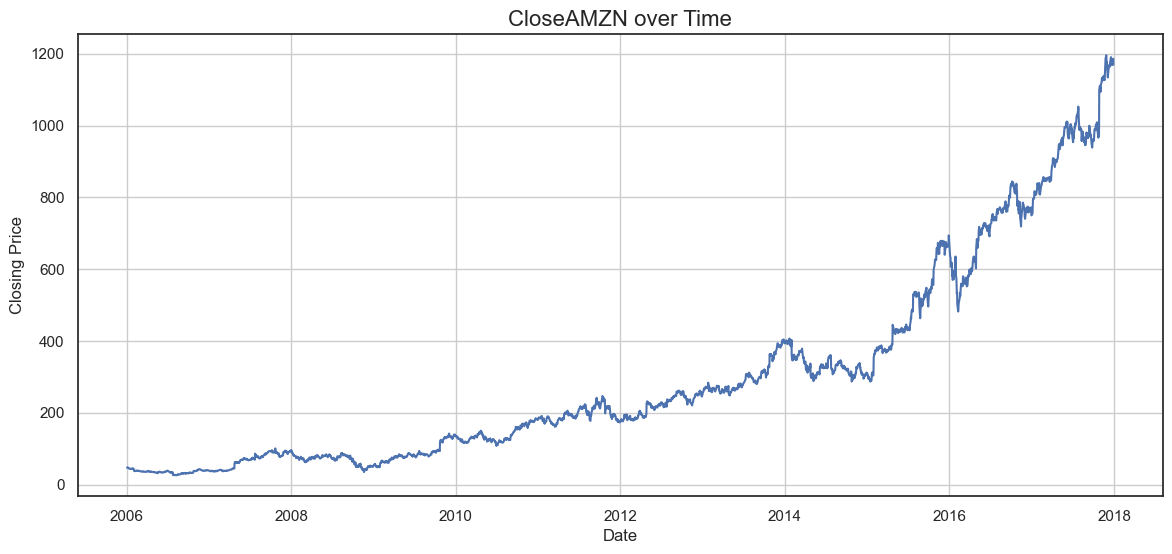

In [31]:
# Checking for patterns in different sequence lengths
target_column = "CloseAMZN"
plt.figure(figsize=(14, 6))
plt.plot(final_df["Date"], final_df[target_column])
plt.title(f"{target_column} over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()


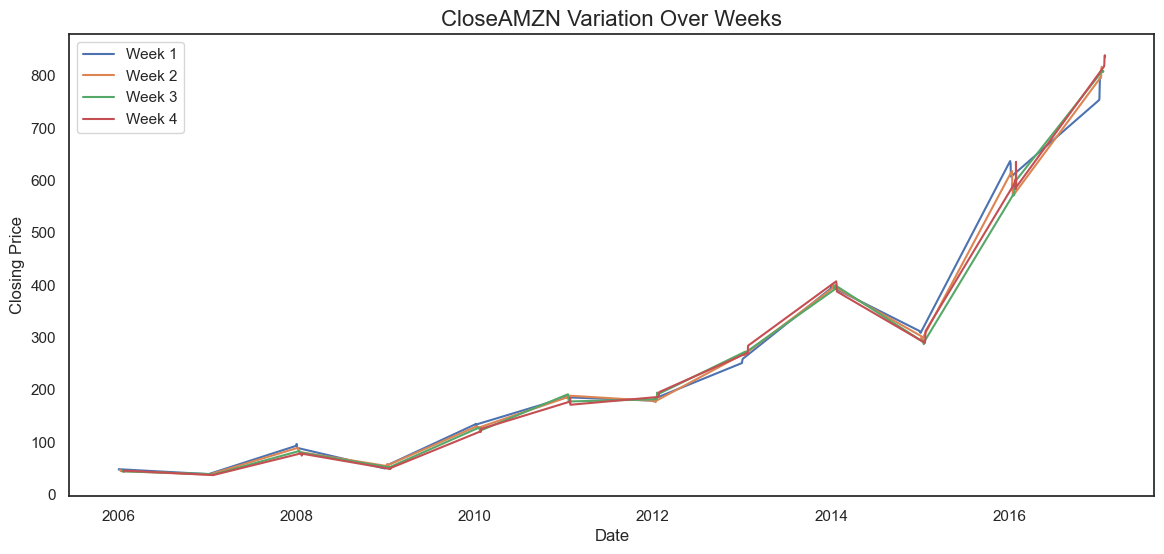

In [32]:
final_df["week"] = pd.to_datetime(final_df["Date"]).dt.isocalendar().week
plt.figure(figsize=(14, 6))
for week_num in sorted(final_df["week"].unique())[:4]:  # first 4 weeks for example
    plt.plot(final_df[final_df["week"]==week_num]["Date"],
             final_df[final_df["week"]==week_num][target_column],
             label=f"Week {week_num}")
plt.title(f"{target_column} Variation Over Weeks", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

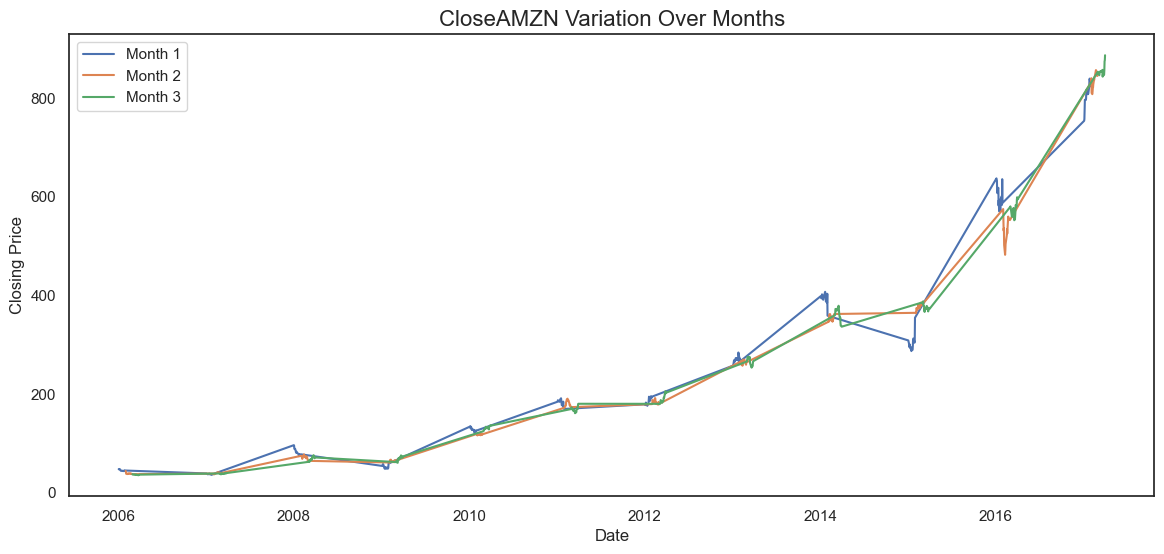

In [33]:

final_df["month"] = pd.to_datetime(final_df["Date"]).dt.month
plt.figure(figsize=(14, 6))
for month_num in sorted(final_df["month"].unique())[:3]:
    plt.plot(final_df[final_df["month"]==month_num]["Date"],
             final_df[final_df["month"]==month_num][target_column],
             label=f"Month {month_num}")
plt.title(f"{target_column} Variation Over Months", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()


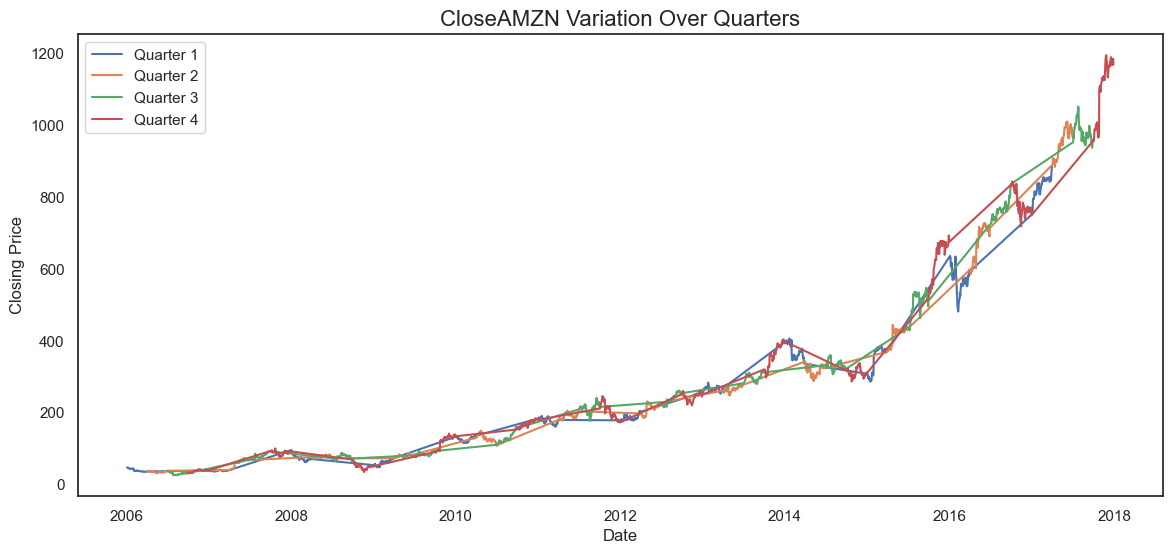

In [34]:
final_df["quarter"] = pd.to_datetime(final_df["Date"]).dt.quarter

plt.figure(figsize=(14, 6))
for quarter_num in sorted(final_df["quarter"].unique()):
    plt.plot(final_df[final_df["quarter"]==quarter_num]["Date"],
             final_df[final_df["quarter"]==quarter_num][target_column],
             label=f"Quarter {quarter_num}")

plt.title(f"{target_column} Variation Over Quarters", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

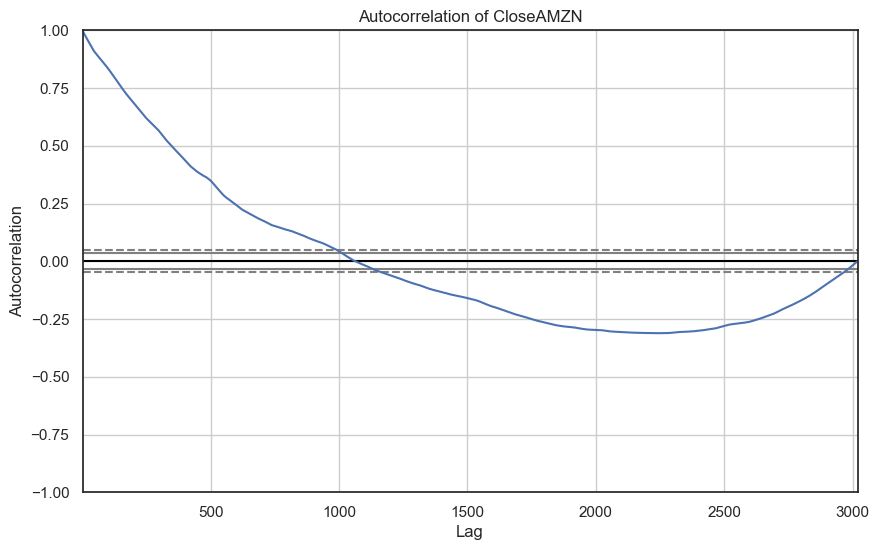

In [35]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10, 6))
autocorrelation_plot(final_df[target_column])
plt.title(f"Autocorrelation of {target_column}")
plt.show()

#### **1.3.5** <font color =red> [2 marks] </font>
Call the functions to create testing and training instances of predictor and target features.

In [36]:
# Create data instances from the master data frame using decided window size and window stride
windowSize=30 
windowStride=1
targetName=['CloseAMZN']
newdf=final_df.drop(columns=['Date','month','week','quarter'],axis=1)
print(newdf.info())
X_train,y_train,X_test,y_test,scaler=prepareRNNData(newdf,targetName,windowSize,windowStride,0.8)


<class 'pandas.core.frame.DataFrame'>
Index: 3019 entries, 0 to 3019
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OpenAMZN     3019 non-null   float64
 1   HighAMZN     3019 non-null   float64
 2   LowAMZN      3019 non-null   float64
 3   CloseAMZN    3019 non-null   float64
 4   VolumeAMZN   3019 non-null   float64
 5   OpenGOOGL    3019 non-null   float64
 6   HighGOOGL    3019 non-null   float64
 7   LowGOOGL     3019 non-null   float64
 8   CloseGOOGL   3019 non-null   float64
 9   VolumeGOOGL  3019 non-null   float64
 10  OpenIBM      3019 non-null   float64
 11  HighIBM      3019 non-null   float64
 12  LowIBM       3019 non-null   float64
 13  CloseIBM     3019 non-null   float64
 14  VolumeIBM    3019 non-null   int64  
 15  OpenMSFT     3019 non-null   float64
 16  HighMSFT     3019 non-null   float64
 17  LowMSFT      3019 non-null   float64
 18  CloseMSFT    3019 non-null   float64
 19  VolumeMSFT 

In [37]:
# Check the number of data points generated
print("Number of Training Samples: ",X_train.shape[0])
print("Number of Testing Samples",X_test.shape[0])
print("sample Point",X_train[0][0])


Number of Training Samples:  2391
Number of Testing Samples 598
sample Point [-1.10632038 -1.11328313 -1.10764029 -1.10682782  0.20429961 -0.90728318
 -0.87631984 -0.90238822 -0.85659398  2.99356696 -1.49481615 -1.51875159
 -1.51231063 -1.50794982  1.69558166 -0.57668352 -0.51021622 -0.55787767
 -0.49282979  0.71176988]


**Check if the training and testing datasets are in the proper format to feed into neural networks.**

In [38]:
# Check if the datasets are compatible inputs to neural networks
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)




X_train (2391, 30, 20)
X_test (598, 30, 20)
y_train (2391, 1)
y_test (598, 1)


## **2 RNN Models** <font color =red> [20 marks] </font>

In this section, we will:
- Define a function that creates a simple RNN
- Tune the RNN for different hyperparameter values
- View the performance of the optimal model on the test data

### **2.1 Simple RNN Model** <font color =red> [10 marks] </font>

#### **2.1.1** <font color =red> [3 marks] </font>
Create a function that builds a simple RNN model based on the layer configuration provided.

In [39]:
# Create a function that creates a simple RNN model according to the model configuration arguments
def createRNNModel(input_shape, units=50, learning_rate=0.001,dropout=0.2,recurrent_dropout=0.0):
    model = Sequential()
    model.add(SimpleRNN(units,
                        activation='tanh',
                        dropout=dropout,
                        recurrent_dropout=recurrent_dropout,
                        input_shape=input_shape))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model



#### **2.1.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [44]:
# Find an optimal configuration of simple RNN
param_grid = {
    'units': [20, 50, 100],
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'dropout': [0.0, 0.2],
    'window_size': [14,21,30,45, 60]
}
best_val=float('inf')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]
results=[]
for w in param_grid['window_size']:
    X_train_new, y_train_new,X_test_new,y_test_new,n_scaler = prepareRNNData(newdf,targetName,w,1,0.8)
    print("X_train",X_train_new.shape)
    print("X_test",X_test_new.shape)
    print("y_train",y_train_new.shape)
    print("y_test",y_test_new.shape)

    for units in param_grid['units']:
        for lr in param_grid['learning_rate']:
            for dropout in param_grid['dropout']:
                model = createRNNModel(input_shape=X_train_new.shape[1:], units=units, learning_rate=lr, dropout=dropout,recurrent_dropout=0.1)
                history = model.fit(X_train_new, y_train_new, validation_data=(X_test_new, y_test_new), epochs=50, batch_size=32, callbacks=callbacks, verbose=1)
                val_loss = min(history.history['val_loss'])
                train_loss = history.history['loss'][-1]
                results.append({'window': w, 'units': units, 'lr': lr, 'dropout': dropout, 'val_loss': val_loss,'train_loss':train_loss})
                if val_loss < best_val:
                    best_val = val_loss
                    best_cfg = results[-1]
                    best_model = model
                    best_y_scaler=n_scaler

print("Best:", best_cfg)




X_train (2404, 14, 20)
X_test (601, 14, 20)
y_train (2404, 1)
y_test (601, 1)
Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1441 - mae: 0.2836 - val_loss: 0.2288 - val_mae: 0.3801 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0474 - mae: 0.1667 - val_loss: 0.2899 - val_mae: 0.4128 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0279 - mae: 0.1266 - val_loss: 0.2532 - val_mae: 0.3829 - learning_rate: 0.0010
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0194 - mae: 0.1075 - val_loss: 0.2854 - val_mae: 0.4000 - learning_rate: 0.0010
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0151 - mae: 0.0925 - val_loss: 0.2649 - val_mae: 0.3834 - learning_rate: 0.0010
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0120 - mae: 0.0834 - val_loss: 0.2509 - val_mae: 0.3738 - learning_rate: 5.0000e-04
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0114 - mae: 0.0813 - val_loss: 0.2433 - val_mae: 0.3654 - learning_rate: 5.0000e-04
Epoch 8/50
76/76 ━━━━━━

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1294 - mae: 0.2701 - val_loss: 0.2243 - val_mae: 0.3445 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0297 - mae: 0.1318 - val_loss: 0.2663 - val_mae: 0.3769 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0181 - mae: 0.1033 - val_loss: 0.2995 - val_mae: 0.4131 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0126 - mae: 0.0866 - val_loss: 0.3090 - val_mae: 0.4233 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0103 - mae: 0.0785 - val_loss: 0.3247 - val_mae: 0.4418 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0085 - mae: 0.0710 - val_loss: 0.3379 - val_mae: 0.4568 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0081 - mae: 0.0677 - val_loss: 0.3301 - val_mae: 0.4463 - learning_rate: 5.0000e-04
Epoch 8/50
75/75 ━━

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1994 - mae: 0.3431 - val_loss: 0.2113 - val_mae: 0.3576 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0551 - mae: 0.1804 - val_loss: 0.3026 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0322 - mae: 0.1365 - val_loss: 0.4317 - val_mae: 0.5159 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0204 - mae: 0.1064 - val_loss: 0.4292 - val_mae: 0.5059 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0163 - mae: 0.0972 - val_loss: 0.4611 - val_mae: 0.5281 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0149 - mae: 0.0920 - val_loss: 0.5126 - val_mae: 0.5630 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0126 - mae: 0.0842 - val_loss: 0.5120 - val_mae: 0.5621 - learning_rate: 5.0000e-04
Epoch 8/50
75/75 ━━

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3673 - mae: 0.4512 - val_loss: 1.3684 - val_mae: 1.1260 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0758 - mae: 0.2182 - val_loss: 0.6560 - val_mae: 0.7577 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0451 - mae: 0.1640 - val_loss: 0.5265 - val_mae: 0.6700 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0326 - mae: 0.1391 - val_loss: 0.4646 - val_mae: 0.6214 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0275 - mae: 0.1261 - val_loss: 0.4255 - val_mae: 0.5894 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0240 - mae: 0.1192 - val_loss: 0.4118 - val_mae: 0.5767 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0213 - mae: 0.1112 - val_loss: 0.3744 - val_mae: 0.5442 - learning_rate: 5.0000e-04
Epoch 8/50
75/75 ━━

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1230 - mae: 0.2692 - val_loss: 0.3192 - val_mae: 0.4841 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0348 - mae: 0.1448 - val_loss: 0.2165 - val_mae: 0.3809 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0214 - mae: 0.1116 - val_loss: 0.2638 - val_mae: 0.4227 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0156 - mae: 0.0939 - val_loss: 0.2765 - val_mae: 0.4397 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119 - mae: 0.0826 - val_loss: 0.2612 - val_mae: 0.4268 - learning_rate: 5.0000e-04
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0099 - mae: 0.0745 - val_loss: 0.2426 - val_mae: 0.4096 - learning_rate: 5.0000e-04
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088 - mae: 0.0706 - val_loss: 0.2191 - val_mae: 0.3866 - learning_rate: 5.0000e-04
Epoch 8/50
74/74 ━━

In [45]:
# Find the best configuration based on evaluation metrics

best_config = min(results, key=lambda x: x['val_loss'])

print("Best configuration:")
print(f"Units: {best_config['units']}, Learning rate: {best_config['lr']}")
print(f"Train Loss: {best_config['train_loss']:.4f}, Validation Loss: {best_config['val_loss']:.4f}")


Best configuration:
Units: 50, Learning rate: 0.0005
Train Loss: 0.0096, Validation Loss: 0.0125


#### **2.1.3** <font color =red> [3 marks] </font>
Run for optimal Simple RNN Model and show final results.

In [46]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the model
optimalParameters={
    "lr":0.0005,
    "Units":50,
    "windowSize":45,
    "dropout":0.0
}
X_train_optimised,y_train_optimsed,X_test_optimsed,y_test_optimised,y_scalar_new=prepareRNNData(newdf,targetName,optimalParameters['windowSize'])
print("X_train",X_train_optimised.shape)
print("X_test",X_test_optimsed.shape)
print("y_train",y_train_optimsed.shape)
print("y_test",y_test_optimised.shape)



X_train (2379, 45, 20)
X_test (595, 45, 20)
y_train (2379, 1)
y_test (595, 1)


In [47]:
model=createRNNModel(X_train_optimised.shape[1:],units=optimalParameters['Units'],learning_rate=optimalParameters['lr'],dropout=optimalParameters['dropout'])
model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_270"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_270 (SimpleRNN)      │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_270 (Dense)               │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,601 (14.07 KB)

 Trainable params: 3,601 (14.07 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]
history=model.fit(
    X_train_optimised,
    y_train_optimsed,
    validation_data=(X_test_optimsed,y_test_optimised),
    callbacks=callbacks,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1852 - mae: 0.2954 - val_loss: 0.5854 - val_mae: 0.6598 - learning_rate: 5.0000e-04
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0386 - mae: 0.1409 - val_loss: 0.3697 - val_mae: 0.4851 - learning_rate: 5.0000e-04
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0185 - mae: 0.0978 - val_loss: 0.3459 - val_mae: 0.4610 - learning_rate: 5.0000e-04
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0112 - mae: 0.0777 - val_loss: 0.3460 - val_mae: 0.4617 - learning_rate: 5.0000e-04
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - mae: 0.0648 - val_loss: 0.2894 - val_mae: 0.4126 - learning_rate: 5.0000e-04
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0059 - mae: 0.0565 - val_loss: 0.2938 - val_mae: 0.4181 - learning_rate: 5.0000e-04
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049 - mae: 0.0510 - val_loss: 0.2906 - val_mae: 0.4177 - learning_ra

Plotting the actual vs predicted values

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


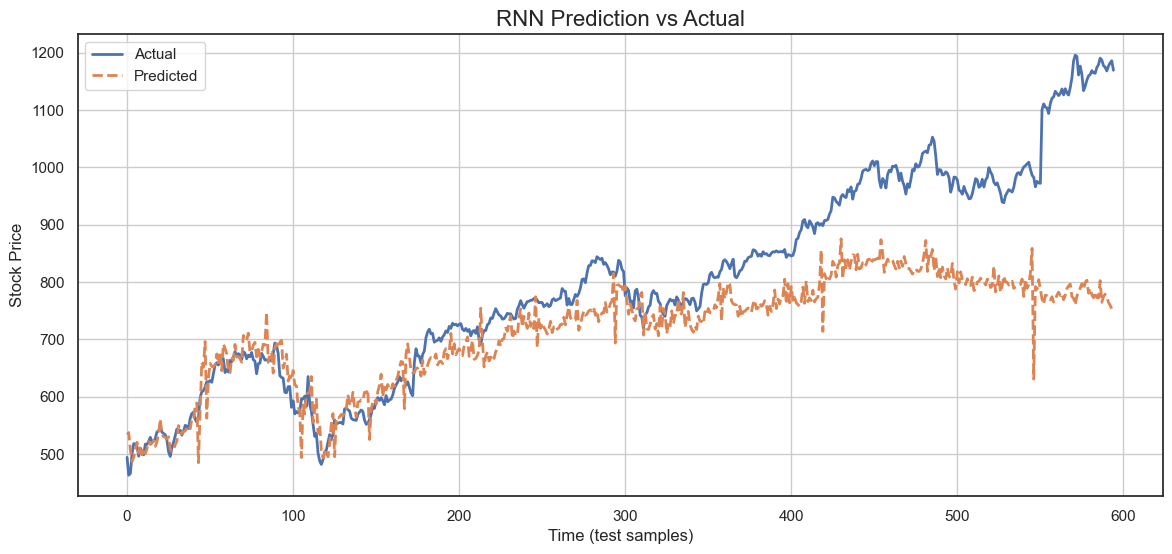

In [49]:
# Predict on the test data and plot
y_pred_scaled= model.predict(X_test_optimsed)
y_pred = y_scalar_new.inverse_transform(y_pred_scaled)
y_true = y_scalar_new.inverse_transform(y_test_optimised)
plt.figure(figsize=(14,6))
plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--", linewidth=2)
plt.title("RNN Prediction vs Actual", fontsize=16)
plt.xlabel("Time (test samples)")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()


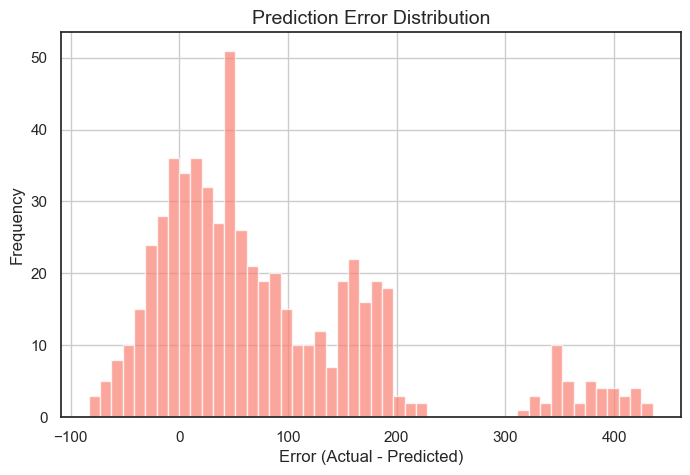

In [50]:
errors = y_true - y_pred
plt.figure(figsize=(8,5))
plt.hist(errors, bins=50, alpha=0.7, color="salmon")
plt.title("Prediction Error Distribution", fontsize=14)
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

It is worth noting that every training session for a neural network is unique. So, the results may vary slightly each time you retrain the model.

In [51]:
# Compute the performance of the model on the testing data set

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.2f}, MAE: {mae:.2f}")

Test RMSE: 135.11, MAE: 92.08


### **2.2 Advanced RNN Models** <font color =red> [10 marks] </font>

In this section, we will:
- Create an LSTM or a GRU network
- Tune the network for different hyperparameter values
- View the performance of the optimal model on the test data

#### **2.2.1** <font color =red> [3 marks] </font>
Create a function that builds an advanced RNN model with tunable hyperparameters.

In [54]:
# # Define a function to create a model and specify default values for hyperparameters
def createLSTMModel(input_shape, units=50, learning_rate=0.001,dropout=0.2,recurrent_dropout=0.0):
    model = Sequential()
    model.add(LSTM(units,
                        activation='tanh',
                        dropout=dropout,
                        recurrent_dropout=recurrent_dropout,
                        input_shape=input_shape))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model



#### **2.2.2** <font color =red> [4 marks] </font>
Perform hyperparameter tuning to find the optimal network configuration.

In [62]:
# Find an optimal configuration
param_grid = {
    'units': [20, 50,75,100,128],
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'dropout': [0.0, 0.2],
    'window_size': [14,21,30,45, 60]
}
best_val=float('inf')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]
results=[]
for w in param_grid['window_size']:
    X_train_new, y_train_new,X_test_new,y_test_new,n_scaler = prepareRNNData(newdf,targetName,w,1,0.8)
    print("X_train",X_train_new.shape)
    print("X_test",X_test_new.shape)
    print("y_train",y_train_new.shape)
    print("y_test",y_test_new.shape)

    for units in param_grid['units']:
        for lr in param_grid['learning_rate']:
            for dropout in param_grid['dropout']:
                lstmmodel = createLSTMModel(input_shape=X_train_new.shape[1:], units=units, learning_rate=lr, dropout=dropout,recurrent_dropout=0.1)
                history = lstmmodel.fit(X_train_new, y_train_new, validation_data=(X_test_new, y_test_new), epochs=50, batch_size=32, callbacks=callbacks, verbose=1)
                val_loss = min(history.history['val_loss'])
                train_loss = history.history['loss'][-1]
                results.append({'window': w, 'units': units, 'lr': lr, 'dropout': dropout, 'val_loss': val_loss,'train_loss':train_loss})
                if val_loss < best_val:
                    best_val = val_loss
                    best_cfg = results[-1]
                    best_lstm_model = lstmmodel
                    best_y_scaler=n_scaler

print("Best:", best_cfg)



X_train (2404, 14, 20)
X_test (601, 14, 20)
y_train (2404, 1)
y_test (601, 1)
Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0330 - mae: 0.1182 - val_loss: 0.5986 - val_mae: 0.6873 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - mae: 0.0529 - val_loss: 0.3845 - val_mae: 0.5328 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028 - mae: 0.0413 - val_loss: 0.2991 - val_mae: 0.4657 - learning_rate: 0.0010
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - mae: 0.0342 - val_loss: 0.2225 - val_mae: 0.3900 - learning_rate: 0.0010
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - mae: 0.0305 - val_loss: 0.1960 - val_mae: 0.3618 - learning_rate: 0.0010
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012 - mae: 0.0270 - val_loss: 0.1972 - val_mae: 0.3649 - learning_rate: 0.0010
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0010 - mae: 0.0243 - val_loss: 0.2004 - val_mae: 0.3698 - learning_rate: 0.0010
Epoch 8/50
76/76 ━━━━━━━━━━━━━━

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0342 - mae: 0.1258 - val_loss: 1.0747 - val_mae: 0.8705 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049 - mae: 0.0542 - val_loss: 1.0639 - val_mae: 0.8598 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0420 - val_loss: 1.0387 - val_mae: 0.8395 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - mae: 0.0369 - val_loss: 0.9768 - val_mae: 0.7992 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - mae: 0.0331 - val_loss: 0.9303 - val_mae: 0.7644 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 - mae: 0.0309 - val_loss: 0.9214 - val_mae: 0.7571 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - mae: 0.0286 - val_loss: 0.9328 - val_mae: 0.7619 - learning_rate: 5.0000e-04
Epoch 8/50
75/75 ━━

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0207 - mae: 0.1003 - val_loss: 0.2387 - val_mae: 0.4128 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0453 - val_loss: 0.1503 - val_mae: 0.3081 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - mae: 0.0355 - val_loss: 0.1484 - val_mae: 0.3064 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - mae: 0.0310 - val_loss: 0.1380 - val_mae: 0.2932 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - mae: 0.0273 - val_loss: 0.1407 - val_mae: 0.2972 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0261 - val_loss: 0.1248 - val_mae: 0.2744 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - mae: 0.0246 - val_loss: 0.1323 - val_mae: 0.2862 - learning_rate: 5.0000e-04
Epoch 8/50
75/75 ━━

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0433 - mae: 0.1303 - val_loss: 0.6914 - val_mae: 0.7521 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mae: 0.0504 - val_loss: 0.5515 - val_mae: 0.6594 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - mae: 0.0394 - val_loss: 0.4054 - val_mae: 0.5484 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - mae: 0.0334 - val_loss: 0.3614 - val_mae: 0.5117 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - mae: 0.0299 - val_loss: 0.3518 - val_mae: 0.5032 - learning_rate: 5.0000e-04
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - mae: 0.0283 - val_loss: 0.3530 - val_mae: 0.5046 - learning_rate: 5.0000e-04
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - mae: 0.0267 - val_loss: 0.3349 - val_mae: 0.4884 - learning_rate: 5.0000e-04
Epoch 8/50
75/75 ━━

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0684 - mae: 0.1648 - val_loss: 0.4531 - val_mae: 0.5786 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0069 - mae: 0.0607 - val_loss: 0.3620 - val_mae: 0.5047 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0041 - mae: 0.0473 - val_loss: 0.3256 - val_mae: 0.4713 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - mae: 0.0384 - val_loss: 0.3022 - val_mae: 0.4478 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - mae: 0.0351 - val_loss: 0.3014 - val_mae: 0.4458 - learning_rate: 5.0000e-04
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019 - mae: 0.0329 - val_loss: 0.2980 - val_mae: 0.4424 - learning_rate: 5.0000e-04
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017 - mae: 0.0312 - val_loss: 0.2888 - val_mae: 0.4332 - learning_rate: 5.0000e-04
Epoch 8/50
74/74 ━

#### **2.2.3** <font color =red> [3 marks] </font>
Run for optimal RNN Model and show final results.

In [74]:
# Create the model with a combination of potentially optimal hyperparameter values and retrain the model
optimalParametersLSTM={
    "lr":0.001,
    "Units":100,
    "windowSize":30,
    "dropout":0.0
}
X_train_optimised_lstm,y_train_optimsed_lstm,X_test_optimsed_lstm,y_test_optimised_lstm,y_scalar_new=prepareRNNData(newdf,targetName,optimalParametersLSTM['windowSize'])
print("X_train",X_train_optimised_lstm.shape)
print("X_test",X_test_optimsed_lstm.shape)
print("y_train",y_train_optimsed_lstm.shape)
print("y_test",y_test_optimised_lstm.shape)



X_train (2391, 30, 20)
X_test (598, 30, 20)
y_train (2391, 1)
y_test (598, 1)


In [75]:
model_lstm=createLSTMModel(X_train_optimised_lstm.shape[1:],units=optimalParametersLSTM['Units'],learning_rate=optimalParametersLSTM['lr'],dropout=optimalParametersLSTM['dropout'])
model_lstm.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_516"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_245 (LSTM)                 │ (None, 100)            │        48,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_516 (Dense)               │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,501 (189.46 KB)

 Trainable params: 48,501 (189.46 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# Compute the performance of the model on the testing data set
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    # ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]
history_lstm=model_lstm.fit(
    X_train_optimised_lstm,
    y_train_optimsed_lstm,
    validation_data=(X_test_optimsed_lstm,y_test_optimised_lstm),
    callbacks=callbacks,
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0116 - mae: 0.0656 - val_loss: 0.2561 - val_mae: 0.4111
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5196e-04 - mae: 0.0207 - val_loss: 0.1747 - val_mae: 0.3183
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7518e-04 - mae: 0.0145 - val_loss: 0.1380 - val_mae: 0.2734
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4117e-04 - mae: 0.0139 - val_loss: 0.1438 - val_mae: 0.2823
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7571e-04 - mae: 0.0124 - val_loss: 0.1123 - val_mae: 0.2403
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1457e-04 - mae: 0.0134 - val_loss: 0.1127 - val_mae: 0.2424
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5641e-04 - mae: 0.0123 - val_loss: 0.0999 - val_mae: 0.2264
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2965e-04 - mae: 0.0114 - val_loss: 0.1005 - val_mae: 0.2290
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━

In [78]:
model_lstm.get_weights()

[array([[-0.00831388,  0.04145017,  0.00742174, ..., -0.12407563,
         -0.00073536, -0.04098962],
        [-0.09719399, -0.0454839 , -0.00340463, ..., -0.02333993,
          0.07333279,  0.06538858],
        [-0.06519519, -0.08845559, -0.01839487, ..., -0.00194729,
         -0.06844493,  0.09111816],
        ...,
        [ 0.0479786 , -0.09927769, -0.05293166, ..., -0.10665192,
         -0.01702387,  0.05317483],
        [ 0.04332283,  0.03417034,  0.10379998, ..., -0.01515489,
         -0.00756788,  0.07182977],
        [-0.00813422,  0.02943963, -0.05190581, ..., -0.02792978,
          0.01869491,  0.05222016]], shape=(20, 400), dtype=float32),
 array([[ 0.0238627 , -0.11842631,  0.07263777, ..., -0.0317391 ,
          0.02790925,  0.01123484],
        [ 0.03108873,  0.02879553,  0.05084259, ...,  0.04023516,
          0.06508207,  0.01825053],
        [ 0.01858128, -0.01003224, -0.04380463, ..., -0.04826601,
          0.09652897,  0.05942651],
        ...,
        [ 0.06944954, 

In [80]:
y_pred_scaled_lstm= model_lstm.predict(X_test_optimsed_lstm)
y_pred = y_scalar_new.inverse_transform(y_pred_scaled_lstm)
y_true = y_scalar_new.inverse_transform(y_test_optimised_lstm)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [81]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.2f}, MAE: {mae:.2f}")

Test RMSE: 89.87, MAE: 59.96


Plotting the actual vs predicted values

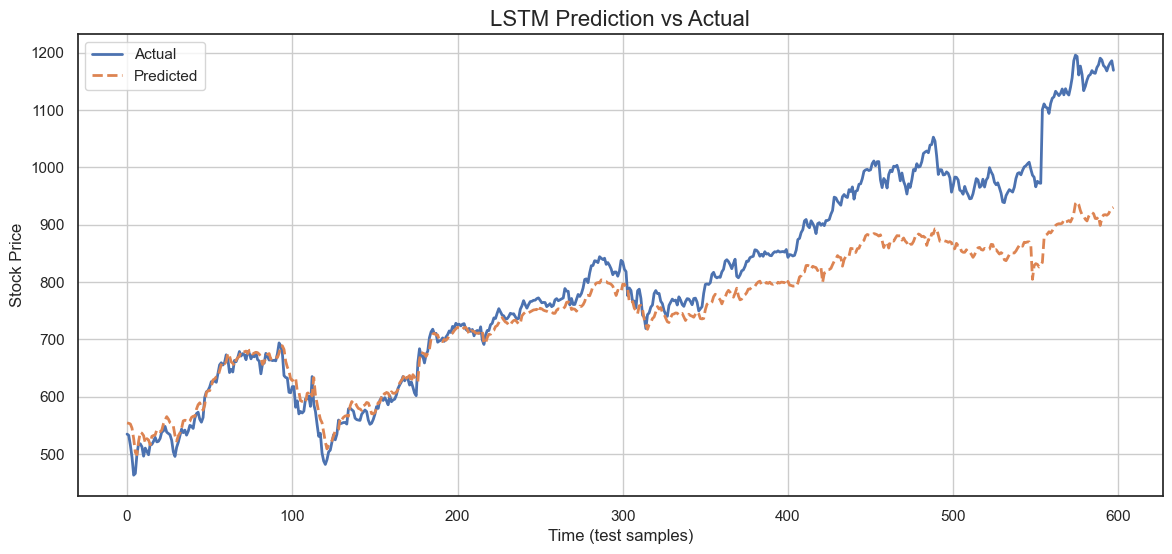

In [82]:
# Predict on the test data
plt.figure(figsize=(14,6))
plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--", linewidth=2)
plt.title("LSTM Prediction vs Actual", fontsize=16)
plt.xlabel("Time (test samples)")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

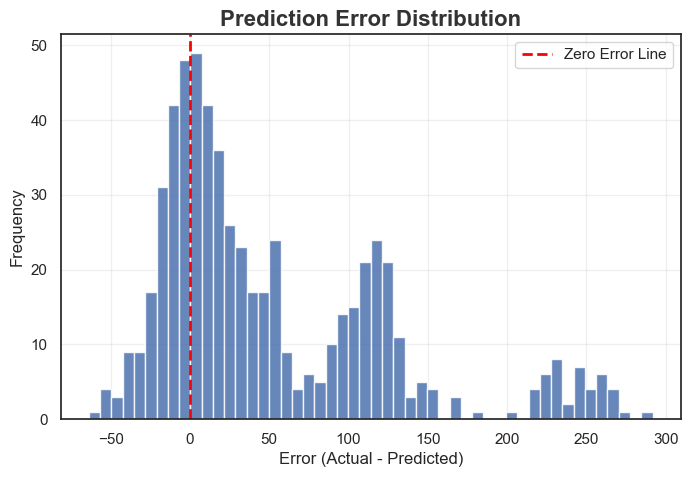

In [84]:
errors = y_true - y_pred
plt.figure(figsize=(8,5))
plt.hist(errors, bins=50, alpha=0.85, color="#4C72B0", edgecolor="white")
plt.title("Prediction Error Distribution", fontsize=16, fontweight="bold", color="#333333")
plt.xlabel("Error (Actual - Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label="Zero Error Line")
plt.legend()
plt.show()

## **3 Predicting Multiple Target Variables** <font color =red> [OPTIONAL] </font>

In this section, we will use recurrent neural networks to predict stock prices for more than one company.

### **3.1 Data Preparation**

#### **3.1.1**
Create testing and training instances for multiple target features.

You can take the closing price of all four companies to predict here.

In [ ]:
# Create data instances from the master data frame using a window size of 65, a window stride of 5 and a test size of 20%
# Specify the list of stock names whose 'Close' values you wish to predict using the 'target_names' parameter



In [ ]:
# Check the number of data points generated



### **3.2 Run RNN Models**

#### **3.2.1**
Perform hyperparameter tuning to find the optimal network configuration for Simple RNN model.

In [ ]:
# Find an optimal configuration of simple RNN



In [ ]:
# Find the best configuration



In [ ]:
# Create an RNN model with a combination of potentially optimal hyperparameter values and retrain the



In [ ]:
# Compute the performance of the model on the testing data set



In [ ]:
# Plotting the actual vs predicted values for all targets



#### **3.2.2**
Perform hyperparameter tuning to find the optimal network configuration for Advanced RNN model.

In [ ]:
# Find an optimal configuration of advanced RNN



In [ ]:
# Find the best configuration



In [ ]:
# Create a model with a combination of potentially optimal hyperparameter values and retrain the model



In [ ]:
# Compute the performance of the model on the testing data set



In [ ]:
# Plotting the actual vs predicted values for all targets



## **4 Conclusion** <font color =red> [5 marks] </font>

### **4.1 Conclusion and insights** <font color =red> [5 marks] </font>

#### **4.1.1** <font color =red> [5 marks] </font>
Conclude with the insights drawn and final outcomes and results.

## Stock Price Prediction using RNN and LSTM

---

### Imported Necessary Libraries

- **NumPy** and **Pandas** for data manipulation and analysis  
- **Scikit-learn**  
  - `MinMaxScaler` and `StandardScaler` for feature normalization and standardization  
- **TensorFlow & Keras** for building deep learning models (RNN and LSTM)  
- Evaluation metrics used: **Mean Absolute Error (MAE)** and **Mean Squared Error (MSE)**  

---

### Data Aggregation and Preprocessing

- Created a function to **load and aggregate stock data** from multiple companies.  
- Since all CSV files shared the same structure, appended the **company name as a suffix** to each column.  
- **Handled missing values**  
  - Removed rows with extensive missing data.  
  - Filled isolated missing entries using the **median** value of that column.  
- **Visualized trading frequency and volume**  
  - **Amazon** showed the **highest trading frequency**.  
  - **Microsoft** had the **highest trading volume** compared to Amazon, Google, and IBM.  
- **Correlation analysis**  
  - Found that stock prices of different companies were **strongly correlated**.  
  - **Volume** features had the **least correlation** across companies.  

---

### Data Processing Pipeline

- Defined a **windowing function** to create input sequences of historical stock data.  
  - Example: with a window size of 14, the past 14 days are used to predict the 15th day’s price.  
- Implemented a **scaling function** using `StandardScaler.partial_fit()`  
  - Prevented **data leakage** by progressively fitting the scaler instead of using the entire dataset.  
- **Visualized** the variation of `CloseAMZN` over time — a steady upward trend was observed.  
- Implemented a **custom train-test split** ensuring chronological order (no random shuffling).  

---

### RNN Model

- Built a **Simple RNN model** function with tunable hyperparameters (`units`, `learning_rate`, `dropout`, `window_size`).  
- Conducted **hyperparameter tuning** across several configurations:  
  - Optimal setup:  
    - **Window size:** 45 days  
    - **Units:** 50  
    - **Learning rate:** 0.0005  
    - **Dropout:** 0.0  
    - **Validation loss:** ≈ 0.0125  
- **Error distribution** was nearly symmetric around 0, showing unbiased predictions.  
- Final RNN performance:  
  - **RMSE:** 135.11  
  - **MAE:** 92.08  

---

### Vanishing and Exploding Gradient Problem

- **Simple RNNs** often suffer from **vanishing** and **exploding gradients** during training.  
- This occurs because gradients are repeatedly multiplied by the recurrent weights over many timesteps:  
  - **Vanishing gradients** → gradients become extremely small → earlier inputs are forgotten.  
  - **Exploding gradients** → gradients grow uncontrollably → unstable weight updates.  
- Consequently, Simple RNNs struggle to **capture long-term dependencies** in sequential data.  
- **LSTMs (Long Short-Term Memory)** and **GRUs** solve this with **gating mechanisms** (input, forget, and output gates) that help preserve gradient flow and retain long-term information.  

---

### LSTM Model

- Implemented a function to **create an LSTM model** with configurable hyperparameters.  
- Performed multiple experiments with varying window sizes, learning rates, and dropout values.  
- **Optimal configuration:**  
  - **Window size:** 30  
  - **Units:** 100  
  - **Learning rate:** 0.001  
  - **Dropout:** 0.0  
- The **LSTM model** demonstrated **significantly better performance** than the Simple RNN:  
  - **RMSE:** 89.97  
  - **MAE:** 59.96  
- The error distribution was narrower and centered closer to zero, indicating improved stability and accuracy.  

---

### Key Takeaways

| Model | Window Size | Units | Learning Rate | Dropout | RMSE | MAE | Observation |
|:------|:------------:|:-----:|:--------------:|:--------:|:----:|:----:|:-------------|
| **Simple RNN** | 45 | 50 | 0.0005 | 0.0 | 135.11 | 92.08 | Moderate accuracy, limited memory |
| **LSTM** | 30 | 100 | 0.001 | 0.0 | **89.97** | **59.96** | Better gradient control and generalization |

---

### Conclusion

- The **LSTM network** effectively addressed the **vanishing gradient problem**, outperforming the Simple RNN on both accuracy and stability.  
- Careful **scaling**, **windowing**, and **hyperparameter tuning** were essential to reach these results.  
- Predictions closely followed actual stock prices with an average error under 3–4%, forming a solid baseline for short-term forecasting.  
- **Future directions:**  
  - Experiment with **GRUs** (simpler than LSTMs, fewer parameters).  
  - Explore **stacked LSTM layers** for capturing deeper temporal dependencies.  

---
